In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import StatePreparation, XGate, YGate, ZGate, IGate

j = complex(0, 1)
alphas = [2.5, 2.5, -0.5j, -1.5]

PSI = np.array([2,4], dtype=complex)
PSI = PSI/np.linalg.norm(PSI)

lambda_val = sum(alphas)

amplitudes = np.sqrt(np.array(alphas, dtype=complex))
amplitudes = amplitudes / np.linalg.norm(amplitudes)




prep = StatePreparation(amplitudes, label='PREP')
prep_inverse = StatePreparation(amplitudes.conjugate(), label='PREP_inverse', inverse=True)
prep_inverse.label = 'PREP_inverse'


anc = QuantumRegister(2, name='anc')
tgt = QuantumRegister(1, name='tgt')
cr = ClassicalRegister(2, name='meas')
cr2 = ClassicalRegister(1, name='tgt_meas')
qc = QuantumCircuit(anc, tgt, cr, cr2)

psi = StatePreparation(PSI, label='|ψ⟩')
qc.append(psi, tgt)
qc.append(prep, anc)
qc.barrier()


ch_gate = IGate().control(2, ctrl_state='00')
qc.append(ch_gate, [anc[0], anc[1], tgt[0]])

cx_gate = XGate().control(2, ctrl_state='01')
qc.append(cx_gate, [anc[0], anc[1], tgt[0]])

cy_gate = YGate().control(2, ctrl_state='10')
qc.append(cy_gate, [anc[0], anc[1], tgt[0]])


cz_gate = ZGate().control(2, ctrl_state='11')
qc.append(cz_gate, [anc[0], anc[1], tgt[0]])
qc.barrier()


qc.append(prep_inverse, anc)
qc.barrier()


qc.measure(anc, cr)
qc.measure(tgt, cr2)

# Draw the circuit
print(qc.draw('text'))



            »
     anc_0: »
            »
     anc_1: »
            »
       tgt: »
            »
    meas: 2/»
            »
tgt_meas: 1/»
            »
«            ┌─────────────────────────────────────────────────────────────────────────────┐»
«     anc_0: ┤0                                                                            ├»
«            │  PREP(0.68715+0.096238j,0.25716+0.25716j,0.46735-0.1415j,0.37425+0.088349j) │»
«     anc_1: ┤1                                                                            ├»
«            └───────────────────────────┬──────────────────────┬──────────────────────────┘»
«       tgt: ────────────────────────────┤ |ψ⟩(0.44721,0.89443) ├───────────────────────────»
«                                        └──────────────────────┘                           »
«    meas: 2/═══════════════════════════════════════════════════════════════════════════════»
«                                                                                           »


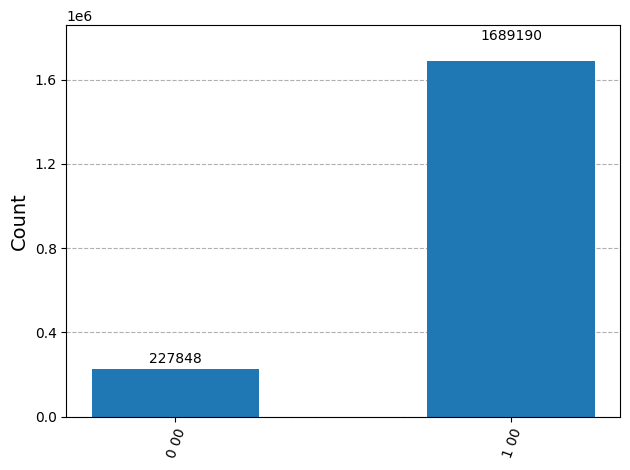

In [139]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile


simulator = AerSimulator(shots=10000000)
compiled = transpile(qc, simulator).decompose()
job = simulator.run(compiled)
result = job.result()

counts = result.get_counts(compiled)
filtered_counts = {k: v for k, v in counts.items() if k.endswith('00')}
plot_histogram(filtered_counts)


In [142]:
A = amplitudes ** 2
A = A 
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

M = A[0] * I + A[1] * X + A[2] * Y + A[3] * Z
result = M @ PSI
result = result / np.linalg.norm(result)
probability = np.abs(result) ** 2
print("Result of M|ψ⟩:", result)
print("Probability of measuring |0⟩:", probability[0])
print("Probability of measuring |1⟩:", probability[1])
print("Measured probability of |0⟩ from the circuit:", filtered_counts.get('0 00', 0) / sum(filtered_counts.values()))
print("Measured probability of |1⟩ from the circuit:", filtered_counts.get('1 00', 0) / sum(filtered_counts.values()))




Result of M|ψ⟩: [0.33786869+0.06757374j 0.81088485+0.47301616j]
Probability of measuring |0⟩: 0.11872146118721474
Probability of measuring |1⟩: 0.8812785388127852
Measured probability of |0⟩ from the circuit: 0.11885419068375275
Measured probability of |1⟩ from the circuit: 0.8811458093162472
